In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load Data
df = pd.read_csv("acc_data_final_with_daynight.csv")

# parse datetime (robust)
df['dt'] = pd.to_datetime(df['date'].astype(str) + " " + df['time'].astype(str),
                          dayfirst=True, errors='coerce')
df = df.dropna(subset=['dt']).sort_values('dt')

#  Aggregate to daily level
df['acc'] = df['เกิดเหตุ'].astype(int)
daily = df.set_index('dt').resample('D').agg({'acc':'sum'}).fillna(0)

# target = daily accident counts
y = daily['acc']

# Build exogenous features (weekday one-hot)
exog = pd.get_dummies(daily.index.dayofweek, prefix="dow", drop_first=True)
exog.index = daily.index  # align index

C:\Users\sakka\AppData\Local\Temp\ipykernel_25820\4091079985.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['dt'] = pd.to_datetime(df['date'].astype(str) + " " + df['time'].astype(str),


In [17]:
# Train/Validation Split (80/20)
train_size = int(len(y)*0.8)
y_train, y_val = y.iloc[:train_size], y.iloc[train_size:]
X_train, X_val = exog.iloc[:train_size], exog.iloc[train_size:]

In [18]:
# Fit SARIMAX (ARIMAX)
# p,d,q = (1,0,1), seasonal = (1,0,1,7)---ปรับได้
model = SARIMAX(y_train,
                order=(1,0,1),
                seasonal_order=(1,0,1,7),
                exog=X_train,
                enforce_stationarity=False,
                enforce_invertibility=False)

res = model.fit(disp=False)
print(res.summary())

                                     SARIMAX Results                                     
Dep. Variable:                               acc   No. Observations:                  292
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -206.817
Date:                           Thu, 18 Sep 2025   AIC                            435.633
Time:                                   00:36:55   BIC                            475.733
Sample:                               01-01-2024   HQIC                           451.712
                                    - 10-18-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dow_1          0.1919      0.097      1.986      0.047       0.003       0.381
dow_2          0.2796      0.098      2.840

In [19]:
# Simple validation (hold-out)
val_forecast = res.get_forecast(steps=len(y_val), exog=X_val)
val_mean = pd.Series(val_forecast.predicted_mean, index=y_val.index).clip(lower=0)
val_prob = 1 - np.exp(-val_mean)

val_mae = float(np.mean(np.abs(val_mean - y_val)))
val_brier = float(np.mean((val_prob - (y_val > 0).astype(int))**2))
print(f"\n[Validation] MAE(count)={val_mae:.4f} | Brier(prob ≥1)={val_brier:.4f}")


[Validation] MAE(count)=0.2301 | Brier(prob ≥1)=0.0866


In [20]:
# Refit on all & Forecast next 14 days
# Refit on all history
model_all = SARIMAX(y, order=(1,0,1), seasonal_order=(1,0,1,7),
                    exog=exog, enforce_stationarity=False, enforce_invertibility=False)
res_all = model_all.fit(disp=False)

horizon = 14
last_day = y.index[-1]
# NOTE: ถ้า y.index เป็น DatetimeIndex อยู่แล้ว จะโอเค
# หากเป็น PeriodIndex ให้แปลงเป็น Timestamp ก่อน
if not isinstance(last_day, pd.Timestamp):
    last_day = pd.Timestamp(last_day.to_timestamp()) if hasattr(last_day, "to_timestamp") else pd.Timestamp(last_day)

future_index = pd.date_range(start=last_day + pd.Timedelta(days=1),
                             periods=horizon, freq='D')

# --- สร้าง exogenous ของอนาคต (weekday one-hot) ให้ตรง schema เดิม ---
X_future = pd.get_dummies(future_index.dayofweek, prefix="dow", drop_first=True)
X_future.index = future_index
# ให้คอลัมน์ตรงกับของ train (เผื่อบางวันในอดีตขาดคอลัมน์)
X_future = X_future.reindex(columns=exog.columns, fill_value=0)

fc = res_all.get_forecast(steps=horizon, exog=X_future)
fc_mean = pd.Series(fc.predicted_mean, index=future_index).clip(lower=0)
fc_ci = fc.conf_int()
fc_ci.index = future_index

# Convert to probability >=1 accident
fc_prob = 1 - np.exp(-fc_mean)   # 1 - e^-λ

# Weekly aggregation (probability ≥1 in the week)
# สมมติความเป็นอิสระรายวันโดยประมาณ:
# P(≥1 ในสัปดาห์) = 1 - product(1 - p_day)
week_prob = (1 - (1 - fc_prob).groupby(pd.Grouper(freq='7D')).prod())
week_prob.index.name = 'week_start'

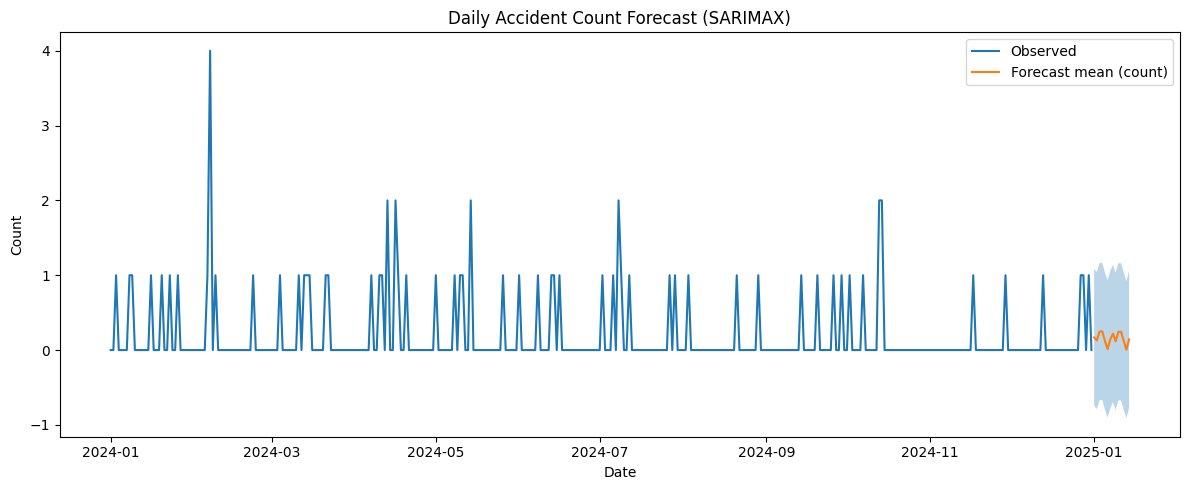

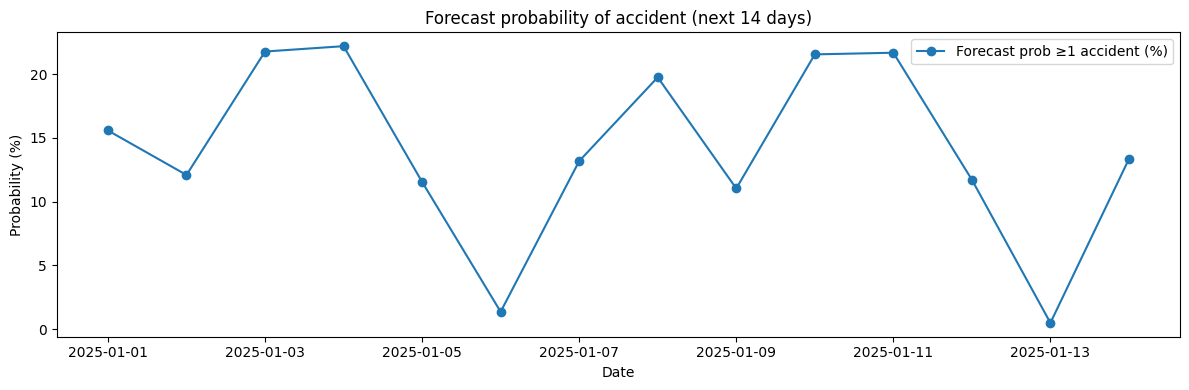

✅ Saved:
 - datacsv/forecast_sarimax_daily.csv
 - datacsv/forecast_sarimax_weekly.csv


In [21]:
# Plots
# Ensure numeric dtype for fill_between
fc_ci = fc_ci.astype(float)
plt.figure(figsize=(12,5))
plt.plot(y.index, y.values, label="Observed")
plt.plot(fc_mean.index, fc_mean.values, label="Forecast mean (count)")
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0].values, fc_ci.iloc[:,1].values, alpha=0.3)
plt.title("Daily Accident Count Forecast (SARIMAX)")
plt.xlabel("Date"); plt.ylabel("Count"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(fc_prob.index, fc_prob.values*100, marker='o', label="Forecast prob ≥1 accident (%)")
plt.title("Forecast probability of accident (next 14 days)")
plt.xlabel("Date"); plt.ylabel("Probability (%)"); plt.legend(); plt.tight_layout(); plt.show()

# Save to CSV
os.makedirs("datacsv", exist_ok=True)

out_daily = pd.DataFrame({
    "date": fc_mean.index,
    "forecast_mean_count": fc_mean.values,
    "ci_lower": fc_ci.iloc[:,0].values,
    "ci_upper": fc_ci.iloc[:,1].values,
    "forecast_prob_ge1": fc_prob.values
})
out_daily.to_csv("datacsv/forecast_sarimax_daily.csv", index=False, encoding="utf-8-sig")

out_week = pd.DataFrame({
    "week_start": week_prob.index,
    "prob_ge1_week": week_prob.values
})
out_week.to_csv("datacsv/forecast_sarimax_weekly.csv", index=False, encoding="utf-8-sig")

print("✅ Saved:")
print(" - datacsv/forecast_sarimax_daily.csv")
print(" - datacsv/forecast_sarimax_weekly.csv")